In [1]:
import time
import torch
import os
import IPython.display as display

if not hasattr(display, "set_matplotlib_formats"):
    # no-op fallback (or you can force retina/png instead)
    def set_matplotlib_formats(*args, **kwargs):
        return None
    display.set_matplotlib_formats = set_matplotlib_formats

from d2l.torch import Animator

from net import Net, NetB
from utils import load_val_dataset, build_pyg_data_split, build_pyg_data
from faco import MFACO_TSP

from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
PRETRAINED_DIR = PROJECT_ROOT / "../pretrained"

# Optional wandb logging (lazy import to avoid hangs at import-time)
USE_WANDB = True
WANDB_PROJECT = os.environ.get("WANDB_PROJECT", "claco")
WANDB_ENTITY = os.environ.get("WANDB_ENTITY") or None
WANDB_MODE = os.environ.get("WANDB_MODE", "online")  # set to "offline" to avoid network
wandb = None

def _wandb_init(config: dict, name: str | None = None):
    """Init a fresh wandb run for each train() call.

    In notebooks it's common to re-run the train cell; reusing the same wandb run
    causes non-monotonic step warnings when we log with an explicit `step=`.
    """
    global wandb, USE_WANDB
    if not USE_WANDB:
        return None
    if wandb is None:
        try:
            import wandb as _wandb
            wandb = _wandb
        except Exception as e:
            USE_WANDB = False
            print("wandb disabled (import failed):", e)
            return None
    if wandb.run is not None:
        # Start a new run to avoid step going backwards on re-runs.
        try:
            wandb.finish()
        except Exception:
            pass
    return wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        config=config,
        name=name,
        mode=WANDB_MODE,
    )

torch.manual_seed(1234)

lr = 1e-4
EPS = 1e-10

H=20
val_H=20
rho = 0.1
min_new_edges = 8
disable_heuristic = True
use_local_search = True
smooth_mmas = False
extend_ls = False

device = 'cuda:0'

# Import your compiled extension (needed for get_max_threads print below)
try:
    import faco_tsp
except Exception as e:
    faco_tsp = None
    print("Warning: could not import faco_tsp:", e)

if faco_tsp is not None:
    print("faco_tsp imported. OpenMP max threads:", faco_tsp.get_max_threads())

faco_tsp imported. OpenMP max threads: 10


In [2]:

import numpy as np
import torch

def _popcount_i64(x: torch.Tensor) -> torch.Tensor:
    """
    Vectorized popcount for int64 tensor x (CUDA-safe).
    Interprets bits in two's complement; for non-negative values this matches uint64 popcount.
    Returns int64 counts in [0, 64].
    """
    if x.dtype != torch.int64:
        raise TypeError(f"_popcount_i64 expects torch.int64, got {x.dtype}")

    # Masks as int64 constants (fit within signed range)
    m1  = x.new_tensor(0x5555555555555555, dtype=torch.int64)
    m2  = x.new_tensor(0x3333333333333333, dtype=torch.int64)
    m4  = x.new_tensor(0x0F0F0F0F0F0F0F0F, dtype=torch.int64)
    h01 = x.new_tensor(0x0101010101010101, dtype=torch.int64)

    # Assumes x is non-negative (your valid_mask should be)
    x = x - ((x >> 1) & m1)
    x = (x & m2) + ((x >> 2) & m2)
    x = (x + (x >> 4)) & m4
    return (x * h01) >> 56


def replay_logp_from_cpp_batch_trace(traces, prob_sparse: torch.Tensor):
    device = prob_sparse.device
    k = int(prob_sparse.size(1))
    if k > 64:
        raise ValueError(f"k={k} > 64 but trace.valid_mask is 64-bit; store n_valid explicitly or widen mask.")

    # Trace arrays -> torch (non-diff)
    curr = torch.as_tensor(np.asarray(traces.curr_nodes, dtype=np.int64), device=device)
    is_stoch = torch.as_tensor(np.asarray(traces.is_stochastic, dtype=np.uint8), device=device).bool()
    used_unif = torch.as_tensor(np.asarray(traces.used_uniform, dtype=np.uint8), device=device).bool()
    pick = torch.as_tensor(np.asarray(traces.pick_j, dtype=np.int64), device=device)

    # IMPORTANT: keep mask as int64 on GPU to allow indexing
    vm_i64 = torch.as_tensor(np.asarray(traces.valid_mask, dtype=np.uint64), device=device).to(torch.int64)

    # Ant mapping on GPU
    starts_t = torch.as_tensor(np.asarray(traces.starts, dtype=np.int64), device=device, dtype=torch.int64)
    n_ants = int(getattr(traces, "n_ants", int(starts_t.numel() - 1)))
    counts_t = (starts_t[1:1+n_ants] - starts_t[:n_ants]).to(torch.int64)

    ant_idx_all = torch.repeat_interleave(
        torch.arange(n_ants, device=device, dtype=torch.int64),
        counts_t,
    )

    # ndec per ant (stochastic only)
    if bool(is_stoch.any().item()):
        ndec = torch.bincount(ant_idx_all[is_stoch], minlength=n_ants).to(torch.int32)
    else:
        ndec = torch.zeros((n_ants,), device=device, dtype=torch.int32)

    logp = torch.zeros((n_ants,), device=device, dtype=torch.float32)

    # --- Roulette steps ---
    roulette = is_stoch & (~used_unif) & (pick >= 0)
    if bool(roulette.any().item()):
        idx = roulette.nonzero(as_tuple=False).squeeze(1)
        curr_r = curr[idx]
        pick_r = pick[idx]

        in_range = (pick_r >= 0) & (pick_r < k)
        if not bool(in_range.all().item()):
            bad = pick_r[~in_range][:10].detach().cpu().tolist()
            raise ValueError(f"pick_j out of range (k={k}). Examples: {bad}")

        vm_r = vm_i64[idx]  # int64, CUDA-indexable
        w = prob_sparse[curr_r]  # (D_r, k), differentiable

        # Build validity matrix from bitmask (all int64 ops, then cast)
        bitpos = torch.arange(k, device=device, dtype=torch.int64)
        valid = ((vm_r.unsqueeze(1) >> bitpos) & 1).to(w.dtype)

        denom = (w * valid).sum(dim=1).clamp_min(1e-12)
        numer = w.gather(1, pick_r.unsqueeze(1)).squeeze(1).clamp_min(1e-12)

        chosen_valid = (((vm_r >> pick_r) & 1) != 0)
        if not bool(chosen_valid.all().item()):
            raise ValueError("Trace inconsistency: pick_j not valid under valid_mask for some roulette decisions.")

        lp = torch.log(numer / denom)
        logp.scatter_add_(0, ant_idx_all[idx], lp)

    # --- Uniform steps ---
    unif = is_stoch & used_unif
    if bool(unif.any().item()):
        idx = unif.nonzero(as_tuple=False).squeeze(1)
        vm_u = vm_i64[idx]  # int64
        m = _popcount_i64(vm_u).to(torch.float32)
        lp = -torch.log(m.clamp_min(1.0))
        logp.scatter_add_(0, ant_idx_all[idx], lp)

    return logp, ndec

In [3]:
def train_instance(model, optimizer, coords, k_sparse, n_ants, dynamic):
    model.train()
    aco = MFACO_TSP(
        n_ants=n_ants,
        coords=coords,
        cand_list_size=k_sparse,
        backup_list_size=k_sparse,
        disable_heuristic=disable_heuristic,
        use_local_search=use_local_search,
        decay=rho,
        device=device,
        enable_torch_sync=True,
        smooth_mmas=smooth_mmas,
        min_new_edges=min_new_edges,
        extend_ls=extend_ls,
    )

    optimizer.zero_grad(set_to_none=True)

    best_seen = float("inf")
    avg_cost_last = None

    for t in range(H):
        pyg_data = build_pyg_data(aco, coords, device, dynamic=dynamic)

        heu_vec = model(pyg_data).view(-1)
        heu_mat = heu_vec.view(aco.n, aco.k) + EPS

        # 1) sample + trace from C++
        costs, flats, _, _, traces = aco.sample(require_prob=True, prior=heu_mat)
        costs_t = torch.as_tensor(costs, device=device, dtype=torch.float32)

        # 2) differentiable prob table for training
        prob_sparse = aco.prob_sparse_torch(prior=heu_mat)
        prob_sparse = prob_sparse.clamp_min(EPS)  # protects log()

        logp_per_ant, _ = replay_logp_from_cpp_batch_trace(traces, prob_sparse)  # (n_ants,)

        # 3) REINFORCE loss (baseline = mean in batch)
        baseline = costs_t.mean()
        adv = (costs_t - baseline).detach()

        w = (t + 1) / H
        loss = w * (adv * logp_per_ant).mean()
        loss.backward()

        # 4) pheromone update (best ant this iter)
        best_idx = int(costs_t.argmin().item())
        best_cost_iter = float(costs[best_idx])
        best_seen = min(best_seen, best_cost_iter)

        with torch.no_grad():
            aco._update_pheromone_from_flat(flats[best_idx], best_cost_iter)

        avg_cost_last = float(costs_t.mean().item())

    # optional but often helpful for stability:
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()
    return avg_cost_last, best_seen


def infer_instance(model, coords, k_sparse, n_ants, dynamic):
    model.eval()
    aco = MFACO_TSP(
        n_ants=n_ants,
        coords=coords,
        cand_list_size=k_sparse,
        backup_list_size=k_sparse,
        disable_heuristic=disable_heuristic,
        use_local_search=use_local_search,
        decay=rho,
        device=device,
        enable_torch_sync=True,
        smooth_mmas=smooth_mmas,
        min_new_edges=min_new_edges,
        extend_ls=extend_ls,
    )

    best_seen = float("inf")
    avg_last = None

    with torch.no_grad():
        for _ in range(H):
            pyg_data = build_pyg_data(aco, coords, device, dynamic=dynamic)
            heu_vec = model(pyg_data).view(-1)
            heu_mat = heu_vec.view(aco.n, aco.k) + EPS

            costs, flats, _, _, _ = aco.sample(require_prob=False, prior=heu_mat)

            avg_last = float(costs.mean())
            best_idx = int(costs.argmin())
            best_cost = float(costs[best_idx])
            best_seen = min(best_seen, best_cost)

            aco._update_pheromone_from_flat(flats[best_idx], best_cost)

    return avg_last, best_seen


In [4]:
def train_epoch(n_node,
                n_ants, 
                k_sparse, 
                epoch, 
                steps_per_epoch, 
                net, 
                optimizer,
                dynamic,
                global_step
                ):

    for step in range(steps_per_epoch):
        coords = np.random.rand(n_node, 2).astype(np.float32)
        avg_cost, best_cost = train_instance(net, optimizer, coords, k_sparse, n_ants, dynamic)
        
        if USE_WANDB and wandb is not None:
            wandb.log({
                "train/avg_cost": float(avg_cost),
                "train/best_cost": float(best_cost),
                "train/epoch": int(epoch),
            }, step=global_step)
        global_step += 1
    return global_step


@torch.no_grad()
def validation(n_ants, epoch, net, val_dataset, k_sparse, animator, dynamic):
    sum_sample_best, sum_aco_best = 0, 0
    
    n = len(val_dataset)
    for coords in val_dataset:
        avg_last, best_seen = infer_instance(net, coords, k_sparse, n_ants, dynamic)
        sum_sample_best += avg_last; sum_aco_best += best_seen
    
    n_val = len(val_dataset)
    avg_last = sum_sample_best/n_val
    avg_aco_best = sum_aco_best/n_val
    if animator:
        animator.add(epoch+1, (avg_last, avg_aco_best))
    
    return avg_last, avg_aco_best

In [5]:
def train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, dynamic):
    net = Net().to(device)
    optimizer = torch.optim.AdamW(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs, eta_min=lr * 0.1)

    val_list = load_val_dataset(n_node, device)
    animator = Animator(xlabel='epoch', xlim=[0, epochs], legend=["Avg. sample obj.", "Best ACO obj."])
    
    avg_last, avg_aco_best = validation(n_ants, -1, net, val_list, k_sparse, animator, dynamic)
    val_results = [(avg_last, avg_aco_best)]

    global_step = 0
    if USE_WANDB and wandb is not None:
        wandb.log({
            "val/avg_last": float(avg_last),
            "val/avg_best": float(avg_aco_best),
            "val/epoch": -1,
        }, step=global_step)
        global_step += 1
    
    sum_time = 0
    best_val = float("inf")
    for epoch in range(0, epochs):
        start = time.time()
        global_step = train_epoch(n_node, n_ants, k_sparse, epoch, steps_per_epoch, net, optimizer, dynamic, global_step=global_step)
        scheduler.step()
        sum_time += time.time() - start
        avg_last, avg_aco_best = validation(n_ants, epoch, net, val_list, k_sparse, animator, dynamic)
        val_results.append((avg_last, avg_aco_best))
        if USE_WANDB and wandb is not None:
            wandb.log({
                "val/avg_last": float(avg_last),
                "val/avg_best": float(avg_aco_best),
                "val/epoch": int(epoch),
            }, step=global_step)
        if avg_aco_best < best_val:
            best_val = avg_aco_best
            torch.save(net.state_dict(), f'{PRETRAINED_DIR}/tsp/tsp{n_node}.pt')
        

    print('total training duration:', sum_time)
    
    for epoch in range(-1, epochs):
        print(f'epoch {epoch}:', val_results[epoch+1])
        
    if USE_WANDB and wandb is not None and wandb.run is not None:
        wandb.finish()

Learn heuristic for TSP100: 

total training duration: 226.8710470199585
epoch -1: (8.600088719278574, 8.018564745783806)
epoch 0: (8.531681280583143, 8.005673937499523)
epoch 1: (8.377572450786829, 7.959268927574158)
epoch 2: (8.221760708838701, 7.910790327936411)
epoch 3: (8.172857243567705, 7.902168910950422)
epoch 4: (8.136175703257322, 7.8985703103244305)
epoch 5: (8.120307758450508, 7.898770958185196)
epoch 6: (8.118683617562056, 7.901827462017536)
epoch 7: (8.094328973442316, 7.889414630830288)
epoch 8: (8.084728613495827, 7.897995006293058)
epoch 9: (8.084299568086863, 7.894668389111757)


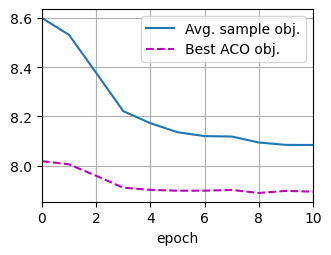

In [ ]:

n_node = 100
n_ants = 100
k_sparse = 32
steps_per_epoch = 64
epochs = 10
min_new_edges = 32

train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

Learn heuristic for TSP500: 

KeyboardInterrupt: 

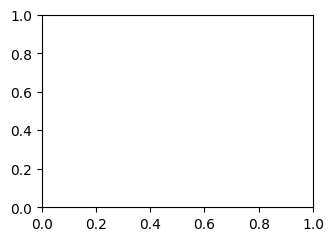

In [7]:

n_node = 200
n_ants = 100
k_sparse = 32
steps_per_epoch = 64
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

KeyboardInterrupt: 

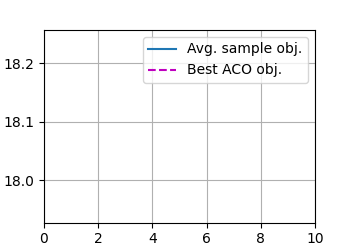

In [ ]:
n_node = 500
n_ants = 100
k_sparse = 32
steps_per_epoch = 64
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

In [ ]:
n_node = 1000
n_ants = 100
k_sparse = 32
steps_per_epoch = 64
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

In [ ]:
n_node = 2000
n_ants = 100
k_sparse = 32
steps_per_epoch = 64
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

In [ ]:
n_node = 5000
n_ants = 100
k_sparse = 32
steps_per_epoch = 64
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)